<a href="https://colab.research.google.com/github/tankim-prio/Uncertainty-Aware-Drone-IDS/blob/main/Drone_IDS_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup & Global Configuration

In [ ]:
# ----------------------------
# Step 0 — Imports + seed
# ----------------------------

import os, random, math, warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import matplotlib

import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

#paper-style plotting defaults
matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(" Imports ready | SEED =", SEED)

 Imports ready | SEED = 42


In [ ]:
# ----------------------------
# Step 1 — Config
# ----------------------------
DATA_PATH = "/content/drive/MyDrive/Drone IDS Dataset Processed/updated_drone_ids_dataset.csv"

TS_COL_CANDIDATES = ["ts", "timestamp", "time", "TS"]
LABEL_COL_CANDIDATES = ["Label_ID", "label", "Label", "Class", "target"]

VAL_FRAC  = 0.10
TEST_FRAC = 0.20

N_CLIENTS = 10                 # 10 clients
SKEW_FEATURE = "Srate"         # feature-skew axis
CLIENT_HOLD_FRAC = 0.10        # per-client holdout

FL_ROUNDS = 8
LOCAL_EPOCHS = 2               # epochs for FL local training
BATCH_SIZE = 256
LR = 1e-3

FEDPROX_MU = 1e-2
FEDDYN_ALPHA = 1e-2

LEAKAGE_AUC_TH = 0.85          # feature hardening cutoff

FIG_DIR = "./figs"
os.makedirs(FIG_DIR, exist_ok=True)

def banner(msg):
    print("\n" + "="*60)
    print(msg)
    print("="*60)

def pick_first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

banner("Step 1 — Config ready ")
print(f"DATA_PATH: {DATA_PATH}")
print(f"SPLIT: VAL={VAL_FRAC:.2f}, TEST={TEST_FRAC:.2f}")
print(f"FL: clients={N_CLIENTS}, rounds={FL_ROUNDS}, local_epochs={LOCAL_EPOCHS}, batch={BATCH_SIZE}")


Step 1 — Config ready 
DATA_PATH: /content/drive/MyDrive/Drone IDS Dataset Processed/updated_drone_ids_dataset.csv
SPLIT: VAL=0.10, TEST=0.20
FL: clients=10, rounds=8, local_epochs=2, batch=256


Cloud Integration & Data Ingestion

In [ ]:
# ----------------------------
# Step 2 — Mount Drive
# ----------------------------
banner("Step 2 — Mount Google Drive")
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Drive mounted at /content/drive")
except Exception as e:
    print(" Not running in Colab / Drive mount skipped:", str(e))


Step 2 — Mount Google Drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at /content/drive


In [ ]:
# Display the first 20 rows
print("--- First 20 Rows of the Dataset ---")
display(df.head(20))

--- First 20 Rows of the Dataset ---


,ts,Payload_Length,Var_Payload,ProtocolType,Duration,Entropy,Drone_port,Rate,Srate,Drate,...,Radius,Covariance,Variance,Weight,DSstatus,Fragments,Sequencenumber,flow_idle_time,flow_active_time,Label
0,0.009172,-1.348014,-0.966191,-0.328831,0.765486,0.002137,-1.037673,-0.372968,-0.098917,-0.006215,...,-0.873068,-0.983958,0.973405,-0.986035,-0.299227,-0.266974,-0.264555,-0.010915,-0.444785,2
1,0.009173,-1.353516,-0.967686,-0.322009,0.972344,0.004068,-1.037673,-0.391071,-0.109245,-0.006215,...,-0.922930,-0.991757,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.519668,-0.432370,2
2,0.009174,-1.376699,-0.958604,-0.328831,0.765486,-0.046176,-1.037673,-0.361644,-0.109251,-0.006215,...,-0.974530,-0.997553,0.730427,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.423013,2
3,0.009175,-1.414617,-0.953677,-0.322009,0.558629,-0.181737,-1.037673,-0.391160,-0.109241,-0.006077,...,-0.877347,-0.981531,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.010915,-0.421956,2
4,0.009175,-1.343496,-0.970667,-0.328831,0.765486,0.002311,-1.037673,-0.380858,-0.109248,-0.006215,...,-0.894850,-0.986919,0.973405,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.405997,2
5,0.009177,-1.402829,-0.958080,-0.328831,0.765486,-0.060538,-1.037673,-0.377262,-0.109256,-0.006215,...,-0.913556,-0.989798,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.519668,-0.395218,2
6,0.009177,-1.346836,-0.971075,-0.328831,0.765486,0.012232,-1.037673,-0.377355,-0.109248,-0.006215,...,-1.074890,-1.008950,0.973405,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.387200,2
7,0.009178,-1.352337,-0.967457,-0.322009,0.972344,0.007790,-1.037673,-0.387845,-0.109248,-0.006215,...,-0.954737,-0.997869,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.519668,-0.368321,2
8,0.009179,-1.375913,-0.963671,-0.328831,0.765486,-0.042152,-1.037673,-0.375255,-0.109252,-0.006215,...,-0.886933,-0.985136,0.973405,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.366479,2
9,0.009180,-1.375520,-0.963560,-0.328831,0.765486,-0.025647,-1.037673,-0.381658,-0.109252,-0.006215,...,-0.902394,-0.987382,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.519668,-0.356187,2


In [ ]:
# Display statistical summary (min, max, std, mean, etc.)
print("\n--- Statistical Summary ---")
display(df.describe())


--- Statistical Summary ---


,ts,Payload_Length,Var_Payload,ProtocolType,Duration,Entropy,Drone_port,Rate,Srate,Drate,...,Radius,Covariance,Variance,Weight,DSstatus,Fragments,Sequencenumber,flow_idle_time,flow_active_time,Label
count,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,...,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000,301555.000000
mean,-0.035422,-0.047982,-0.203550,-0.071684,0.099336,0.099642,-0.037480,0.088726,-0.022150,-0.002767,...,-0.172948,-0.204135,0.049150,-0.002231,-0.066142,-0.059038,-0.057645,-0.114775,0.420522,3.554207
std,0.866823,1.083663,0.915809,0.892550,1.013152,0.943734,0.999934,0.991908,0.895243,0.608013,...,0.944989,0.922669,0.975754,0.997003,0.891134,0.889996,0.890410,0.907625,1.612659,3.714769
min,-1.530916,-1.608923,-0.989828,-0.391925,-1.789361,-1.200121,-1.353331,-0.391285,-0.109292,-0.006215,...,-1.171170,-1.017349,-1.456373,-1.462720,-0.299227,-0.266974,-0.264555,-0.519668,-0.448012,0.000000
25%,-0.934100,-1.349979,-0.989828,-0.322009,-1.096227,-1.200121,-1.037673,-0.374169,-0.109206,-0.006215,...,-1.171170,-1.017349,-1.456373,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.385251,0.000000
50%,0.008516,0.497209,-0.649707,-0.322009,0.764403,0.713296,0.866327,-0.316959,-0.108277,-0.006215,...,-0.261072,-0.573609,0.730427,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.117735,1.000000
75%,0.731844,0.903112,0.439390,-0.322009,0.972344,0.915647,0.866398,0.073047,-0.107885,-0.005892,...,0.753093,0.569967,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.519668,0.234142,9.000000
max,1.211772,1.281115,4.979299,3.025035,0.972344,1.037142,0.866434,19.134081,10.450686,278.658152,...,2.069846,2.904214,0.973405,1.265580,7.525948,12.905968,12.358943,2.022997,30.119993,9.000000


In [ ]:
# ----------------------------
# Step 3 — Load dataset (Basic Information)
# ----------------------------
banner("Step 3 — Load dataset (Basic Information)")
df = pd.read_csv(DATA_PATH)

df.columns = (df.columns.astype(str).str.strip()
              .str.replace(" ", "").str.replace("-", ""))

ts_col = pick_first_existing(df.columns, [c.replace(" ", "") for c in TS_COL_CANDIDATES])
y_col  = pick_first_existing(df.columns, [c.replace(" ", "") for c in LABEL_COL_CANDIDATES])

if ts_col is None:
    raise ValueError("No timestamp column found. Add correct name in TS_COL_CANDIDATES.")
if y_col is None:
    raise ValueError(" No label column found. Add correct name in LABEL_COL_CANDIDATES.")

print(f"Loaded | shape: {df.shape}")
print("first cols:", df.columns.tolist()[:10], "...")


Step 3 — Load dataset (Basic Information)
Loaded | shape: (301555, 63)
first cols: ['ts', 'Payload_Length', 'Var_Payload', 'ProtocolType', 'Duration', 'Entropy', 'Drone_port', 'Rate', 'Srate', 'Drate'] ...


Target Formulation & Data Sanitation

In [ ]:

# ----------------------------
# Step 4 — Label build (Binary)
# ----------------------------
banner("Step 4 — Build Binary_Label")
df[y_col] = df[y_col].astype(int)
df["Binary_Label"] = (df[y_col] != 0).astype(int)
print("Binary_Label distribution:")
print(df["Binary_Label"].value_counts())


Step 4 — Build Binary_Label
Binary_Label distribution:
Binary_Label
1    211907
0     89648
Name: count, dtype: int64


In [ ]:

# ----------------------------
# Step 5 — Handle Missing/Inf values
# ----------------------------
banner("Step 5 — Handle Missing/Inf values")
before = len(df)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(axis=0).reset_index(drop=True)
after = len(df)
print(f" removed rows due to NaN/Inf: {before-after} | now shape={df.shape}")


Step 5 — Handle Missing/Inf values
 removed rows due to NaN/Inf: 0 | now shape=(301555, 64)


Temporal Zero-Day Split Simulation


Step 6 — Leakage-safe split (time holdout)
splits: (211088, 64) (30156, 64) (60311, 64)
Plotting attack-rate drift over time...


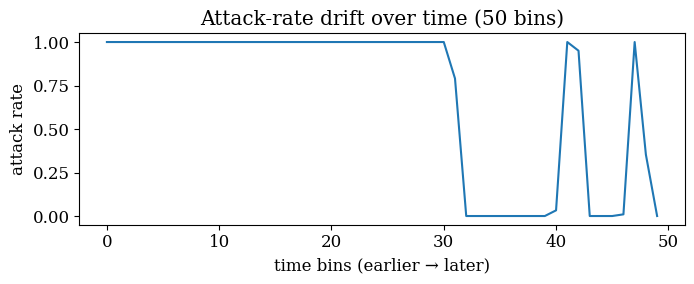

Saved: ./figs/attack_rate_drift.png


In [ ]:

# ----------------------------
# Step 6 — Leakage-safe split (time holdout)
# ----------------------------
banner("Step 6 — Leakage-safe split (time holdout)")
df = df.sort_values(ts_col).reset_index(drop=True)

n = len(df)
n_test = int(round(TEST_FRAC * n))
test_df = df.iloc[-n_test:].copy()
remain_df = df.iloc[:-n_test].copy()

inner_val = VAL_FRAC / (1.0 - TEST_FRAC)
y_remain = remain_df["Binary_Label"].to_numpy().astype(int)

sss = StratifiedShuffleSplit(n_splits=1, test_size=inner_val, random_state=SEED)
tr_pos, va_pos = next(sss.split(np.zeros(len(remain_df)), y_remain))

train_df = remain_df.iloc[tr_pos].copy().reset_index(drop=True)
val_df   = remain_df.iloc[va_pos].copy().reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("splits:", train_df.shape, val_df.shape, test_df.shape)
print("Plotting attack-rate drift over time...")
df_tmp = df[[ts_col, "Binary_Label"]].copy()
df_tmp["_bin"] = pd.qcut(df_tmp[ts_col], q=50, duplicates="drop")
rate = df_tmp.groupby("_bin")["Binary_Label"].mean().values

plt.figure(figsize=(7, 3))
plt.plot(rate)
plt.title("Attack-rate drift over time (50 bins)")
plt.xlabel("time bins (earlier → later)")
plt.ylabel("attack rate")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attack_rate_drift.png", dpi=240)
plt.show()
plt.close()
print(f"Saved: {FIG_DIR}/attack_rate_drift.png")

Data Leakage Prevention & Cross-Split Guard

In [ ]:
# ----------------------------
# Step 7 — Cross-split duplicate guard (hash, train wins)
# ----------------------------
banner("Step 7 — Cross-split duplicate guard (hash)")
drop_cols_for_hash = {y_col, "Binary_Label", ts_col}
feature_cols_all = [c for c in df.columns if c not in drop_cols_for_hash]

def row_hash(d, cols):
    tmp = d[cols].copy()
    ncols = tmp.select_dtypes(include=[np.number]).columns
    if len(ncols) > 0:
        tmp[ncols] = tmp[ncols].round(5)
    return pd.util.hash_pandas_object(tmp, index=False).values

h_train = set(row_hash(train_df, feature_cols_all))
h_val = row_hash(val_df, feature_cols_all)
h_test = row_hash(test_df, feature_cols_all)

val_keep = np.array([h not in h_train for h in h_val])
test_keep = np.array([h not in h_train for h in h_test])

val_removed = int((~val_keep).sum())
test_removed = int((~test_keep).sum())

val_df = val_df.loc[val_keep].copy().reset_index(drop=True)
test_df = test_df.loc[test_keep].copy().reset_index(drop=True)

print(f"removed cross-split duplicates | val_removed={val_removed} | test_removed={test_removed}")


Step 7 — Cross-split duplicate guard (hash)
removed cross-split duplicates | val_removed=651 | test_removed=0


Feature Hardening & Robust Representation


Step 8 — Feature Hardening & Preprocessing
 removed constant cols: 4
Dropped 8 'leaky' numeric features (AUC > 0.85).
Remaining robust features: 49 (num=49 | cat=0)
X shapes: (211088, 49) (29505, 49) (60311, 49)
Plotting label counts by split...


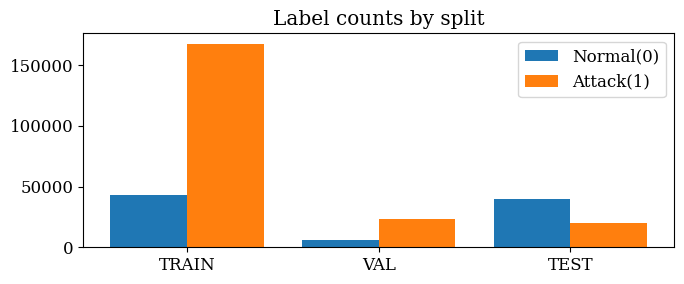

 Saved: ./figs/label_counts_splits.png


In [ ]:
# ----------------------------
# Step 8 — Feature Hardening & Preprocessing
# ----------------------------
banner("Step 8 — Feature Hardening & Preprocessing")
drop_cols = {y_col, "Binary_Label", ts_col}
feature_cols = [c for c in train_df.columns if c not in drop_cols]

nuniq = train_df[feature_cols].nunique(dropna=False)
const_cols = nuniq[nuniq <= 1].index.tolist()
feature_cols = [c for c in feature_cols if c not in const_cols]
if len(const_cols) > 0:
    print(f" removed constant cols: {len(const_cols)}")

num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_df[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

y_tr_bin = train_df["Binary_Label"].to_numpy().astype(int)
robust_num = []
dropped = 0

for c in num_cols:
    try:
        auc = roc_auc_score(y_tr_bin, train_df[c].to_numpy())
        if max(auc, 1-auc) <= LEAKAGE_AUC_TH:
            robust_num.append(c)
        else:
            dropped += 1
    except Exception:
        robust_num.append(c)

num_cols = robust_num
feature_cols = num_cols + cat_cols

print(f"Dropped {dropped} 'leaky' numeric features (AUC > {LEAKAGE_AUC_TH}).")
print(f"Remaining robust features: {len(feature_cols)} (num={len(num_cols)} | cat={len(cat_cols)})")

enc = None
if len(cat_cols) > 0:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    enc.fit(train_df[cat_cols].astype(str))

scaler = StandardScaler()
if len(num_cols) > 0:
    scaler.fit(train_df[num_cols].to_numpy(np.float32))
else:
    scaler.fit(np.zeros((len(train_df), 1), dtype=np.float32))

def transform(d):
    X_num = scaler.transform(d[num_cols].to_numpy(np.float32)) if len(num_cols) > 0 else np.zeros((len(d), 0), dtype=np.float32)
    X_cat = enc.transform(d[cat_cols].astype(str)) if (enc is not None and len(cat_cols) > 0) else np.zeros((len(d), 0), dtype=np.float32)
    return np.hstack([X_num, X_cat]).astype(np.float32)

X_train = transform(train_df)
X_val   = transform(val_df)
X_test  = transform(test_df)

# ensure contiguous float32 (runtime-friendly, no logic change)
X_train = np.ascontiguousarray(X_train, dtype=np.float32)
X_val   = np.ascontiguousarray(X_val,   dtype=np.float32)
X_test  = np.ascontiguousarray(X_test,  dtype=np.float32)

y_train = train_df["Binary_Label"].to_numpy().astype(int)
y_val   = val_df["Binary_Label"].to_numpy().astype(int)
y_test  = test_df["Binary_Label"].to_numpy().astype(int)

print("X shapes:", X_train.shape, X_val.shape, X_test.shape)

print("Plotting label counts by split...")
def count01(y):
    return int((y == 0).sum()), int((y == 1).sum())

tr0, tr1 = count01(y_train)
va0, va1 = count01(y_val)
te0, te1 = count01(y_test)

plt.figure(figsize=(7, 3))
x = np.arange(3)
plt.bar(x-0.2, [tr0, va0, te0], width=0.4, label="Normal(0)")
plt.bar(x+0.2, [tr1, va1, te1], width=0.4, label="Attack(1)")
plt.xticks(x, ["TRAIN", "VAL", "TEST"])
plt.title("Label counts by split")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/label_counts_splits.png", dpi=240)
plt.show()
plt.close()
print(f" Saved: {FIG_DIR}/label_counts_splits.png")

Class Imbalance Resolution & Data Recap


Step 9 — TRAIN Oversampling (Classic ML only)
before | Normal(0)=43324 Attack(1)=167764 pos_rate=0.7948
after  | Normal(0)=167764 Attack(1)=167764 pos_rate=0.5000 | n=335528


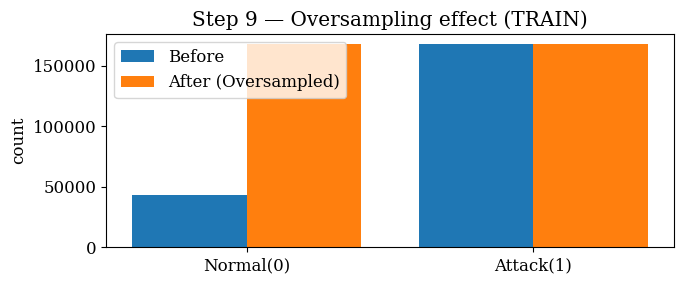

 Saved: ./figs/oversampling_before_after.png


In [ ]:

# ----------------------------
# Step 9 — TRAIN Oversampling (Classic ML) + GRAPH
# ----------------------------
banner("Step 9 — TRAIN Oversampling (Classic ML only)")
n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()
pos_rate = n1 / max(1, (n0 + n1))
print(f"before | Normal(0)={n0} Attack(1)={n1} pos_rate={pos_rate:.4f}")

rng = np.random.RandomState(SEED)
idx0 = np.where(y_train == 0)[0]
idx1 = np.where(y_train == 1)[0]
if len(idx0) == 0 or len(idx1) == 0:
    raise ValueError("TRAIN has only one class. Split/labels need checking.")

need0 = len(idx1) - len(idx0)
if need0 > 0:
    extra0 = rng.choice(idx0, size=need0, replace=True)
    idx_os = np.concatenate([idx0, extra0, idx1])
else:
    need1 = len(idx0) - len(idx1)
    extra1 = rng.choice(idx1, size=max(0, need1), replace=True)
    idx_os = np.concatenate([idx0, idx1, extra1])

rng.shuffle(idx_os)
X_train_os = X_train[idx_os]
y_train_os = y_train[idx_os]

n0a = (y_train_os == 0).sum()
n1a = (y_train_os == 1).sum()
print(f"after  | Normal(0)={n0a} Attack(1)={n1a} pos_rate={(n1a/(n0a+n1a)):.4f} | n={len(y_train_os)}")

# --- requested graph: before vs after ---
plt.figure(figsize=(7, 3))
labels = ["Normal(0)", "Attack(1)"]
before_counts = [n0, n1]
after_counts  = [n0a, n1a]
x = np.arange(len(labels))
plt.bar(x-0.2, before_counts, width=0.4, label="Before")
plt.bar(x+0.2, after_counts,  width=0.4, label="After (Oversampled)")
plt.xticks(x, labels)
plt.title("Step 9 — Oversampling effect (TRAIN)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/oversampling_before_after.png", dpi=240)
plt.show()
plt.close()
print(f" Saved: {FIG_DIR}/oversampling_before_after.png")

In [ ]:
# ----------------------------
# Step 10 — Split recap
# ----------------------------
banner("Step 10 — Split recap (easy)")
print(f"TRAIN  : n={len(y_train)} | Normal={tr0} | Attack={tr1}")
print(f"VAL    : n={len(y_val)}   | Normal={va0} | Attack={va1}")
print(f"TEST   : n={len(y_test)}  | Normal={te0} | Attack={te1}")


Step 10 — Split recap (easy)
TRAIN  : n=211088 | Normal=43324 | Attack=167764
VAL    : n=29505   | Normal=6189 | Attack=23316
TEST   : n=60311  | Normal=40135 | Attack=20176


Advanced Evaluation Metrics & Youden's Optimization

In [ ]:

# ----------------------------
# Helpers — Metrics, Thresholds, & Plots
# ----------------------------
banner("Helpers — metrics, threshold, plots")

def clip01(p, eps=1e-7):
    """Safely clips probabilities to avoid log(0) errors."""
    return np.clip(p, eps, 1 - eps)

def ece_binary(y, p, n_bins=15):
    """Calculates Expected Calibration Error (ECE) for binary classification."""
    p = clip01(p)
    pred = (p >= 0.5).astype(int)
    conf = np.maximum(p, 1 - p)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i + 1])
        if np.any(m):
            ece += (np.sum(m) / len(y)) * abs(np.mean(pred[m] == y[m]) - np.mean(conf[m]))
    return float(ece)

def best_thr_f1(yv, pv):
    """
    ALGORITHM: Youden's J Statistic Threshold Tuning
    Instead of biased F1 optimization, this mathematically finds the optimal
    decision boundary by maximizing both Sensitivity (Recall) and Specificity.
    Formula: J = (True Positive Rate) + (True Negative Rate) - 1
    """
    pv = clip01(pv)
    best_t, best_score = 0.5, -1

    for t in np.linspace(0.05, 0.95, 181):
        yhat = (pv >= t).astype(int)

        # Calculate confusion matrix elements
        tn, fp, fn, tp = confusion_matrix(yv, yhat, labels=[0, 1]).ravel()

        # Calculate Rates
        recall = tp / max(1, (tp + fn))       # True Positive Rate (Sensitivity)
        specificity = tn / max(1, (tn + fp))  # True Negative Rate

        # Youden's J Statistic
        j_stat = recall + specificity - 1

        if j_stat > best_score:
            best_score = j_stat
            best_t = t

    return float(best_t), float(best_score)

def eval_block(name, y_true, p, thr):
    """Evaluates the model and prints all metrics to 7 decimal places."""
    p = clip01(p)
    yhat = (p >= thr).astype(int)

    acc = accuracy_score(y_true, yhat)
    prec = precision_score(y_true, yhat, zero_division=0)
    rec  = recall_score(y_true, yhat, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
    spec = tn / max(1, (tn + fp))

    f1v  = f1_score(y_true, yhat, average="macro", zero_division=0)
    auc  = roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan
    ll   = float(log_loss(y_true, p, labels=[0, 1]))
    br   = float(brier_score_loss(y_true, p))
    ece  = ece_binary(y_true, p)

    # 7-Digit Precision Print Statement
    print(f"\n{name}")
    print(f"  ACC={acc:.7f} | Prec={prec:.7f} | Rec={rec:.7f} | Spec={spec:.7f} | F1(Macro)={f1v:.7f} | AUC={auc:.7f} | LogLoss={ll:.7f} | Brier={br:.7f} | ECE={ece:.7f} | thr={thr:.2f}")

    return {
        "Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec,
        "Specificity": spec, "F1_Macro": f1v, "ROC_AUC": auc,
        "LogLoss": ll, "Brier": br, "ECE": ece, "thr": thr
    }

def show_and_save_cm(y_true, y_pred, title, path):
    """Generates and saves the Confusion Matrix visually."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Attack(1)"])
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=240)
    plt.show()
    plt.close(fig)

def reliability_plot(y, p, path, n_bins=15):
    """Generates the calibration reliability diagram."""
    p = clip01(p)
    bins = np.linspace(0, 1, n_bins + 1)
    xs, ys = [], []
    for i in range(n_bins):
        m = (p > bins[i]) & (p <= bins[i + 1])
        if np.any(m):
            xs.append(np.mean(p[m]))
            ys.append(np.mean(y[m]))
    plt.figure(figsize=(5.2, 4.2))
    plt.plot([0, 1], [0, 1])
    if len(xs):
        plt.plot(xs, ys, marker="o")
    plt.title("Reliability diagram (calibration)")
    plt.xlabel("mean predicted probability")
    plt.ylabel("empirical positive rate")
    plt.tight_layout()
    plt.savefig(path, dpi=240)
    plt.show()
    plt.close()


Helpers — metrics, threshold, plots


Centralized Baselines Training & Benchmarking


Step 11 — Classic ML (Binary): DT / RF / KNN (oversampled train)
⏳ Training DT / RF / KNN on oversampled TRAIN...
✅ Done training. Now tuning thresholds on VAL using Youden's J...
✅ Tuned thresholds | DT=0.05, RF=0.47, KNN=0.27
🧪 Evaluating on TEST...

DT(Bin) TEST
  ACC=0.9715806 | Prec=0.9270843 | Rec=0.9931602 | Spec=0.9607325 | F1(Macro)=0.9686215 | AUC=0.9769464 | LogLoss=0.4580661 | Brier=0.0284194 | ECE=0.0284193 | thr=0.05

RF(Bin) TEST
  ACC=0.9907148 | Prec=0.9729938 | Rec=1.0000000 | Spec=0.9860471 | F1(Macro)=0.9896433 | AUC=0.9999495 | LogLoss=0.0265453 | Brier=0.0078907 | ECE=0.0163936 | thr=0.47

KNN(Bin) TEST
  ACC=0.9842981 | Prec=0.9574630 | Rec=0.9973731 | Spec=0.9777252 | F1(Macro)=0.9825440 | AUC=0.9961960 | LogLoss=0.0842502 | Brier=0.0093842 | ECE=0.0066819 | thr=0.27

[Binary ML Summary — TEST]
        Model  Accuracy Precision    Recall Specificity  F1_Macro   ROC_AUC       ECE  thr
 RF(Bin) TEST 0.9907148 0.9729938 1.0000000   0.9860471 0.9896433 0.9999495 0.

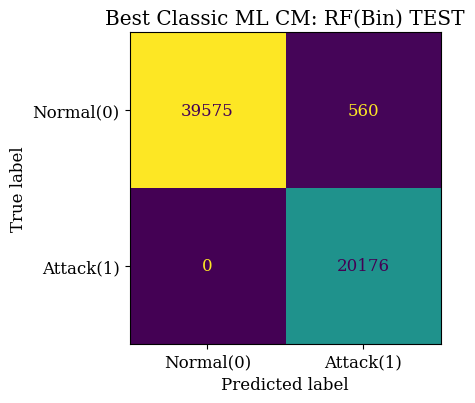

✅ Saved: ./figs/best_classic_ml_cm.png


In [ ]:
## ----------------------------
# Step 11 — Classic ML (Binary): DT / RF / KNN
# ----------------------------
banner("Step 11 — Classic ML (Binary): DT / RF / KNN (oversampled train)")
print("Training DT / RF / KNN on oversampled TRAIN...")

dt = DecisionTreeClassifier(random_state=SEED)
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, min_samples_leaf=2)
knn = KNeighborsClassifier(n_neighbors=15)

dt.fit(X_train_os, y_train_os)
rf.fit(X_train_os, y_train_os)
knn.fit(X_train_os, y_train_os)

print("Done training. Now tuning thresholds on VAL using Youden's J...")

p_dt_val  = dt.predict_proba(X_val)[:, 1]
p_rf_val  = rf.predict_proba(X_val)[:, 1]
p_knn_val = knn.predict_proba(X_val)[:, 1]

thr_dt,  _ = best_thr_f1(y_val, p_dt_val)
thr_rf,  _ = best_thr_f1(y_val, p_rf_val)
thr_knn, _ = best_thr_f1(y_val, p_knn_val)

print(f"Tuned thresholds | DT={thr_dt:.2f}, RF={thr_rf:.2f}, KNN={thr_knn:.2f}")
print("Evaluating on TEST...")

p_dt  = dt.predict_proba(X_test)[:, 1]
p_rf  = rf.predict_proba(X_test)[:, 1]
p_knn = knn.predict_proba(X_test)[:, 1]

res_ml = [
    eval_block("DT(Bin) TEST",  y_test, p_dt,  thr_dt),
    eval_block("RF(Bin) TEST",  y_test, p_rf,  thr_rf),
    eval_block("KNN(Bin) TEST", y_test, p_knn, thr_knn)
]

ml_df = pd.DataFrame(res_ml).sort_values("F1_Macro", ascending=False)

# Apply 7-digit formatting to all metric columns for the table
metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1_Macro", "ROC_AUC", "ECE"]
for col in metric_cols:
    ml_df[col] = ml_df[col].map(lambda x: f"{x:.7f}")

banner("[Binary ML Summary — TEST]")
print(ml_df[["Model"] + metric_cols + ["thr"]].to_string(index=False))

best_ml = ml_df.iloc[0]
best_name = best_ml["Model"]
best_thr  = float(best_ml["thr"])
best_p = {"DT(Bin) TEST": p_dt, "RF(Bin) TEST": p_rf, "KNN(Bin) TEST": p_knn}[best_name]
best_pred = (clip01(best_p) >= best_thr).astype(int)

print(f"\nBest Classic ML by TEST F1_Macro: {best_name} (thr={best_thr:.2f})")
show_and_save_cm(y_test, best_pred, f"Best Classic ML CM: {best_name}", f"{FIG_DIR}/best_classic_ml_cm.png")
print(f"Saved: {FIG_DIR}/best_classic_ml_cm.png")

Model Calibration & Reliability Analysis


Step 12 — Calibration (RandomForest) + ECE (VAL-calibrated)
 Calibrating RF using VAL... (sigmoid / prefit)

Calibrated RF (VAL→TEST)
  ACC=0.9906319 | Prec=0.9727593 | Rec=1.0000000 | Spec=0.9859225 | F1(Macro)=0.9895515 | AUC=0.9999495 | LogLoss=0.0388620 | Brier=0.0084144 | ECE=0.0129036 | thr=0.45


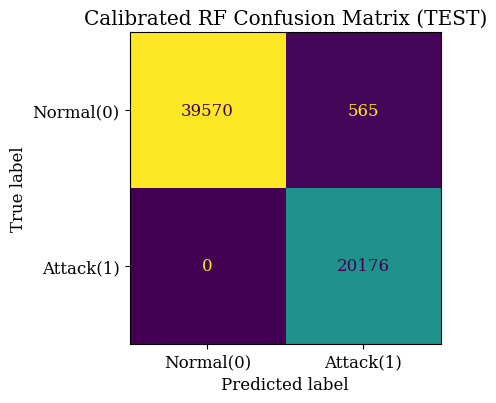

 Saved: ./figs/calibrated_rf_test_cm.png


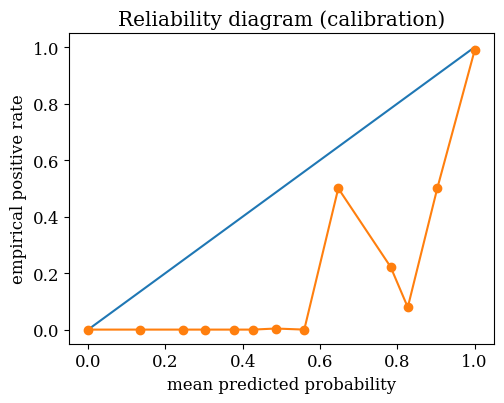

 Saved: ./figs/calibrated_rf_reliability_test.png


In [ ]:
# ----------------------------
# Step 12 — Calibration (RandomForest)
# ----------------------------
banner("Step 12 — Calibration (RandomForest) + ECE (VAL-calibrated)")
print(" Calibrating RF using VAL... (sigmoid / prefit)")

cal = CalibratedClassifierCV(rf, method="sigmoid", cv="prefit")
cal.fit(X_val, y_val)

p_cal_val = cal.predict_proba(X_val)[:, 1]
thr_cal, _ = best_thr_f1(y_val, p_cal_val)

p_cal_test = cal.predict_proba(X_test)[:, 1]
_ = eval_block("Calibrated RF (VAL→TEST)", y_test, p_cal_test, thr_cal)

pred_cal = (clip01(p_cal_test) >= thr_cal).astype(int)
show_and_save_cm(
    y_test, pred_cal,
    "Calibrated RF Confusion Matrix (TEST)",
    f"{FIG_DIR}/calibrated_rf_test_cm.png"
)
print(f" Saved: {FIG_DIR}/calibrated_rf_test_cm.png")

reliability_plot(y_test, p_cal_test, f"{FIG_DIR}/calibrated_rf_reliability_test.png")
print(f" Saved: {FIG_DIR}/calibrated_rf_reliability_test.png")

Federated Environment Prep & Non-IID Partitioning

In [ ]:
# ----------------------------
# Step 13 — XAI metadata prep (feature names)
# ----------------------------
banner("Step 13 — XAI metadata prep")
FEATURE_NAMES = feature_cols[:]  # aligns with transform() order (num + cat)
print(f"FEATURE_NAMES ready | n={len(FEATURE_NAMES)} | example:", FEATURE_NAMES[:8])


Step 13 — XAI metadata prep
FEATURE_NAMES ready | n=49 | example: ['Payload_Length', 'ProtocolType', 'Duration', 'Entropy', 'Drone_port', 'Rate', 'Drate', 'fin_flag_number']


In [ ]:

# ----------------------------
# Step 14 — Non-IID Clients (feature-skew ONLY, label ratio preserved)
# ----------------------------
banner("Step 14 — Non-IID Clients (feature-skew only, label ratio preserved)")

if SKEW_FEATURE not in train_df.columns:
    SKEW_FEATURE = num_cols[0] if len(num_cols) else feature_cols[0]
    print(f"SKEW_FEATURE not found. Using: {SKEW_FEATURE}")

sk = train_df[SKEW_FEATURE].to_numpy()
idx_all = np.arange(len(train_df))
idx0 = idx_all[y_train == 0]
idx1 = idx_all[y_train == 1]

idx0_sorted = idx0[np.argsort(sk[idx0])]
idx1_sorted = idx1[np.argsort(sk[idx1])]

chunks0 = np.array_split(idx0_sorted, N_CLIENTS)
chunks1 = np.array_split(idx1_sorted, N_CLIENTS)

def safe_split_idx(idxs, y, hold_frac, seed):
    y_sub = y[idxs]
    try:
        tr, ho = train_test_split(idxs, test_size=hold_frac, random_state=seed, stratify=y_sub)
    except Exception:
        tr, ho = train_test_split(idxs, test_size=hold_frac, random_state=seed, stratify=None)
    return np.array(tr), np.array(ho)

n0 = int((y_train == 0).sum()); n1 = int((y_train == 1).sum()); n_all = n0 + n1
w0 = n_all / (2.0 * max(1, n0))
w1 = n_all / (2.0 * max(1, n1))
GLOBAL_CLASS_W = {0: float(w0), 1: float(w1)}
print(f"GLOBAL class_w for FL: {GLOBAL_CLASS_W}")

clients = []
for cid in range(N_CLIENTS):
    idx_c = np.concatenate([chunks0[cid], chunks1[cid]])
    if len(idx_c) < 200:
        continue
    tr_idx, ho_idx = safe_split_idx(idx_c, y_train, CLIENT_HOLD_FRAC, SEED)
    clients.append({
        "cid": cid,
        "X_tr":   X_train[tr_idx], "y_tr": y_train[tr_idx].astype(np.int32),
        "X_hold": X_train[ho_idx], "y_hold": y_train[ho_idx].astype(np.int32),
        "class_w": GLOBAL_CLASS_W
    })

print(f"Requested clients: {N_CLIENTS} | Built clients: {len(clients)}")
for c in clients:
    c0 = int((c["y_tr"] == 0).sum()); c1 = int((c["y_tr"] == 1).sum())
    print(f"client {c['cid']+1}: n={len(c['y_tr'])} | Normal={c0} Attack={c1}")


Step 14 — Non-IID Clients (feature-skew only, label ratio preserved)
GLOBAL class_w for FL: {0: 2.436155479641769, 1: 0.629121861662812}
Requested clients: 10 | Built clients: 10
client 1: n=18999 | Normal=3900 Attack=15099
client 2: n=18999 | Normal=3900 Attack=15099
client 3: n=18999 | Normal=3900 Attack=15099
client 4: n=18999 | Normal=3900 Attack=15099
client 5: n=18997 | Normal=3899 Attack=15098
client 6: n=18997 | Normal=3899 Attack=15098
client 7: n=18997 | Normal=3899 Attack=15098
client 8: n=18997 | Normal=3899 Attack=15098
client 9: n=18997 | Normal=3899 Attack=15098
client 10: n=18997 | Normal=3899 Attack=15098


Custom FL Architecture & Uncertainty Function

In [ ]:
# ----------------------------
# Step 15 — FL model + helpers (logits + dropout + class-weighted loss)
# ----------------------------
banner("Step 15 — FL Helpers (logits + dropout + class-weighted loss)")
INPUT_DIM = X_train.shape[1]
print(f"INPUT_DIM = {INPUT_DIM}")
print(f"FL hyperparams | rounds={FL_ROUNDS} local_epochs={LOCAL_EPOCHS} batch={BATCH_SIZE} lr={LR}")
print(f"FedProx mu={FEDPROX_MU} | FedDyn alpha={FEDDYN_ALPHA}")
print(f"Global class weights (FL): {GLOBAL_CLASS_W}")

def build_fl_model(d):
    inp = layers.Input(shape=(d,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(1)(x)   # logits
    return models.Model(inp, out)

tmp_m = build_fl_model(INPUT_DIM)
print(f"FL model params: {tmp_m.count_params():,}")
tmp_m.summary()

def sigmoid_probs_from_logits(logits, T=1.0):
    return tf.sigmoid(logits / T).numpy().reshape(-1)

def tune_temperature(logits_val, yv):
    Ts = [0.6, 0.8, 1.0, 1.2, 1.5, 2.0]
    bestT, bestNLL = 1.0, 1e18
    z = logits_val.reshape(-1)
    for T in Ts:
        p = 1.0 / (1.0 + np.exp(-(z / T)))
        nll = float(log_loss(yv, clip01(p), labels=[0, 1]))
        if nll < bestNLL:
            bestNLL, bestT = nll, T
    return float(bestT)

def metrics_probs(y_true, p, thr=0.5):
    p = clip01(p)
    yhat = (p >= thr).astype(int)
    acc = accuracy_score(y_true, yhat)
    prec = precision_score(y_true, yhat, zero_division=0)
    rec = recall_score(y_true, yhat, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
    spec = tn / max(1, (tn + fp))

    f1v  = f1_score(y_true, yhat, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan
    ll  = float(log_loss(y_true, p, labels=[0, 1]))
    br  = float(brier_score_loss(y_true, p))
    ece = ece_binary(y_true, p)

    return acc, prec, rec, spec, f1v, auc, ll, br, ece

def local_train(model, X, y, class_w, lr=LR, bs=BATCH_SIZE, epochs=LOCAL_EPOCHS,
                global_vars=None, mu=0.0, h=None, alpha=0.0):
    opt = tf.keras.optimizers.Adam(lr)

    w0t = tf.constant(class_w.get(0, 1.0), dtype=tf.float32)
    w1t = tf.constant(class_w.get(1, 1.0), dtype=tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(min(len(X), 20000), seed=SEED).batch(bs).prefetch(tf.data.AUTOTUNE)

    for _ in range(epochs):
        for xb, yb in ds:
            yb = tf.cast(tf.reshape(yb, (-1, 1)), tf.float32)
            with tf.GradientTape() as tape:
                logits = model(xb, training=True)

                per_ex = tf.nn.sigmoid_cross_entropy_with_logits(labels=yb, logits=logits)
                weights = tf.where(yb > 0.5, w1t, w0t)
                bce = tf.reduce_mean(per_ex * weights)
                loss = bce

                if mu > 0.0 and global_vars is not None:
                    prox = tf.add_n([tf.reduce_sum(tf.square(v - gv)) for v, gv in zip(model.trainable_variables, global_vars)])
                    loss = loss + (mu / 2.0) * prox

                if alpha > 0.0 and h is not None and global_vars is not None:
                    lin = tf.add_n([tf.reduce_sum(v * hv) for v, hv in zip(model.trainable_variables, h)])
                    quad = tf.add_n([tf.reduce_sum(tf.square(v - gv)) for v, gv in zip(model.trainable_variables, global_vars)])
                    loss = loss + lin + (alpha / 2.0) * quad

            grads = tape.gradient(loss, model.trainable_variables)
            opt.apply_gradients(zip(grads, model.trainable_variables))
    return model

def weighted_avg(weights_list, sizes):
    total = float(np.sum(sizes))
    out = []
    for k in range(len(weights_list[0])):
        w = sum((sizes[i] / total) * weights_list[i][k] for i in range(len(weights_list)))
        out.append(w)
    return out


Step 15 — FL Helpers (logits + dropout + class-weighted loss)
INPUT_DIM = 49
FL hyperparams | rounds=8 local_epochs=2 batch=256 lr=0.001
FedProx mu=0.01 | FedDyn alpha=0.01
Global class weights (FL): {0: 2.436155479641769, 1: 0.629121861662812}
FL model params: 14,721


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 0 (0.00 B)

Federated Algorithms Training & Aggregation Loop


Step 16 — Federated Learning Training (separate models)
Starting FL training... This can be slow (normal) because each round trains many client models.
[FedAvg] round 1/8 | acc=0.8487375 prec=0.9900192 rec=0.8168211 spec=0.9689772 f1(mac)=0.8119637 auc=0.9460659
[FedAvg] round 2/8 | acc=0.8275885 prec=0.9938235 rec=0.7867130 spec=0.9815802 f1(mac)=0.7915509 auc=0.9620307
[FedAvg] round 3/8 | acc=0.8199966 prec=0.9940728 rec=0.7768485 spec=0.9825497 f1(mac)=0.7840917 auc=0.9668789
[FedAvg] round 4/8 | acc=0.8230808 prec=0.9939943 rec=0.7808372 spec=0.9822265 f1(mac)=0.7871179 auc=0.9729924
[FedAvg] round 5/8 | acc=0.8227758 prec=0.9940453 rec=0.7804083 spec=0.9823881 f1(mac)=0.7868295 auc=0.9751516
[FedAvg] round 6/8 | acc=0.8249449 prec=0.9942275 rec=0.7830245 spec=0.9828728 f1(mac)=0.7890279 auc=0.9789504
[FedAvg] round 7/8 | acc=0.8271479 prec=0.9941942 rec=0.7858552 spec=0.9827113 f1(mac)=0.7912101 auc=0.9806479
[FedAvg] round 8/8 | acc=0.8309439 prec=0.9943360 rec=0.7905730 spec=0

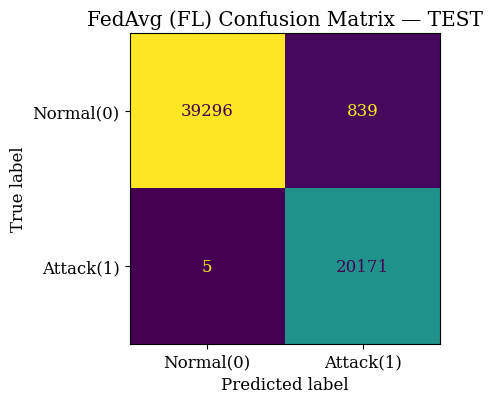

aved FL CM & Weights: FedAvg
[FedProx] round 1/8 | acc=0.8937807 prec=0.9889524 rec=0.8753646 spec=0.9631604 f1(mac)=0.8602710 auc=0.9677999
[FedProx] round 2/8 | acc=0.8696492 prec=0.9917660 rec=0.8420398 spec=0.9736630 f1(mac)=0.8344366 auc=0.9799753
[FedProx] round 3/8 | acc=0.8785968 prec=0.9928571 rec=0.8525047 spec=0.9768945 f1(mac)=0.8444061 auc=0.9848070
[FedProx] round 4/8 | acc=0.8803593 prec=0.9932197 rec=0.8544347 spec=0.9780255 f1(mac)=0.8464269 auc=0.9868059
[FedProx] round 5/8 | acc=0.8851381 prec=0.9926816 rec=0.8609967 spec=0.9760866 f1(mac)=0.8515534 auc=0.9878991
[FedProx] round 6/8 | acc=0.8908660 prec=0.9928389 rec=0.8681592 spec=0.9764098 f1(mac)=0.8579738 auc=0.9891617
[FedProx] round 7/8 | acc=0.8941874 prec=0.9931621 rec=0.8721050 spec=0.9773792 f1(mac)=0.8617902 auc=0.9896439
[FedProx] round 8/8 | acc=0.8919844 prec=0.9935756 rec=0.8689312 spec=0.9788334 f1(mac)=0.8594114 auc=0.9898283

FedProx Final (TEST)
  ACC=0.9687619 | Prec=0.9146717 | Rec=0.9999009 | Sp

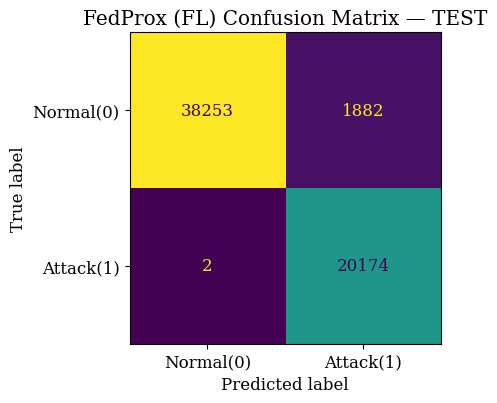

aved FL CM & Weights: FedProx
[FedNova] round 1/8 | acc=0.8295543 prec=0.9903996 rec=0.7919883 spec=0.9710777 f1(mac)=0.7925887 auc=0.9449933
[FedNova] round 2/8 | acc=0.8059651 prec=0.9953816 rec=0.7579774 spec=0.9867507 f1(mac)=0.7707351 auc=0.9598491
[FedNova] round 3/8 | acc=0.8111845 prec=0.9951448 rec=0.7647967 spec=0.9859428 f1(mac)=0.7757393 auc=0.9703660
[FedNova] round 4/8 | acc=0.8124725 prec=0.9952102 rec=0.7663836 spec=0.9861044 f1(mac)=0.7770117 auc=0.9759602
[FedNova] round 5/8 | acc=0.8176580 prec=0.9950320 rec=0.7731172 spec=0.9854581 f1(mac)=0.7820421 auc=0.9791811
[FedNova] round 6/8 | acc=0.8148449 prec=0.9950641 rec=0.7695145 spec=0.9856196 f1(mac)=0.7792919 auc=0.9793525
[FedNova] round 7/8 | acc=0.8230808 prec=0.9950755 rec=0.7799794 spec=0.9854581 f1(mac)=0.7874026 auc=0.9816150
[FedNova] round 8/8 | acc=0.8270463 prec=0.9947303 rec=0.7852976 spec=0.9843270 f1(mac)=0.7912502 auc=0.9827221

FedNova Final (TEST)
  ACC=0.9855748 | Prec=0.9587056 | Rec=0.9999504 | S

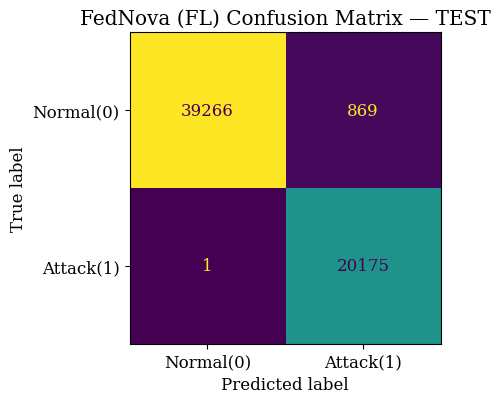

aved FL CM & Weights: FedNova
[FedDyn] round 1/8 | acc=0.8652771 prec=0.9866640 rec=0.8408818 spec=0.9571821 f1(mac)=0.8283709 auc=0.9612472
[FedDyn] round 2/8 | acc=0.9090663 prec=0.9872939 rec=0.8964659 spec=0.9565358 f1(mac)=0.8774744 auc=0.9806943
[FedDyn] round 3/8 | acc=0.9285206 prec=0.9885280 rec=0.9202265 spec=0.9597673 f1(mac)=0.9011969 auc=0.9889219
[FedDyn] round 4/8 | acc=0.9561769 prec=0.9876445 rec=0.9565106 spec=0.9549200 f1(mac)=0.9366119 auc=0.9911741
[FedDyn] round 5/8 | acc=0.9735977 prec=0.9858578 rec=0.9806571 spec=0.9470027 f1(mac)=0.9604678 auc=0.9925427
[FedDyn] round 6/8 | acc=0.9769870 prec=0.9867544 rec=0.9840882 spec=0.9502343 f1(mac)=0.9654209 auc=0.9934345
[FedDyn] round 7/8 | acc=0.9787494 prec=0.9869929 rec=0.9861040 spec=0.9510422 f1(mac)=0.9679898 auc=0.9938413
[FedDyn] round 8/8 | acc=0.9814269 prec=0.9879554 rec=0.9885486 spec=0.9545969 f1(mac)=0.9719649 auc=0.9944078

FedDyn Final (TEST)
  ACC=0.9672033 | Prec=0.9107530 | Rec=0.9999504 | Spec=0.950

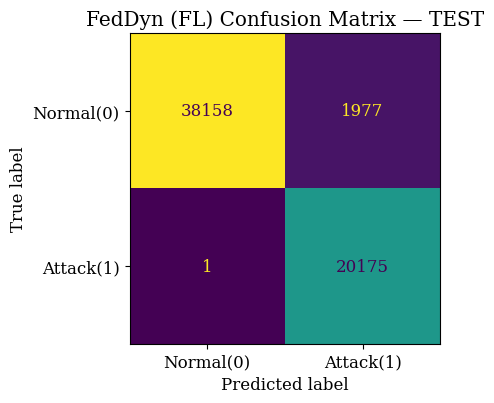

aved FL CM & Weights: FedDyn

FINAL FL COMPARISON
               Model  Accuracy Precision    Recall Specificity  F1_Macro   ROC_AUC   LogLoss       ECE  thr   T
 FedAvg Final (TEST) 0.9860059 0.9600666 0.9997522   0.9790956 0.9844413 0.9996446 0.0169464 0.0026675 0.05 2.0
FedNova Final (TEST) 0.9855748 0.9587056 0.9999504   0.9783481 0.9839684 0.9997361 0.0184572 0.0031123 0.05 2.0
FedProx Final (TEST) 0.9687619 0.9146717 0.9999009   0.9531083 0.9656778 0.9996082 0.0304564 0.0165939 0.06 2.0
 FedDyn Final (TEST) 0.9672033 0.9107530 0.9999504   0.9507412 0.9640030 0.9986859 0.0753883 0.0495116 0.15 1.5

 Plotting FL validation F1(Macro) curves...


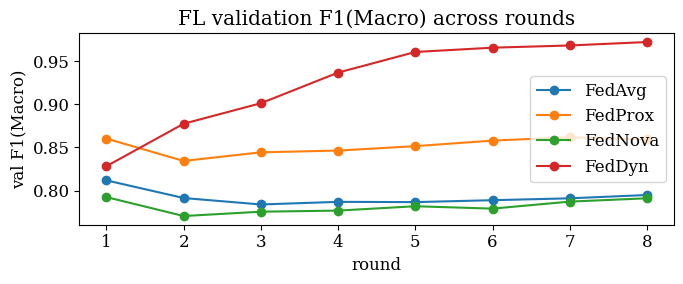

In [ ]:
# ----------------------------
# Step 16 — Federated Learning Training (separate models)
# ----------------------------
banner("Step 16 — Federated Learning Training (separate models)")
print("Starting FL training... This can be slow (normal) because each round trains many client models.")

if len(clients) == 0:
    raise ValueError("No clients found. Please run Step 14 (client build) first.")

def run_fl(name, algo):
    tf.keras.backend.clear_session()
    curves = {"round": [], "val_acc": [], "val_prec": [], "val_rec": [], "val_spec": [], "val_f1_macro": [], "val_auc": []}
    g = build_fl_model(INPUT_DIM)

    h_list = [[tf.zeros_like(v) for v in build_fl_model(INPUT_DIM).trainable_variables] for _ in clients] if algo == "feddyn" else None

    for r in range(1, FL_ROUNDS + 1):
        gw = g.get_weights()
        local_ws, sizes = [], []
        global_vars = [tf.constant(w) for w in gw] if algo in ["fedprox", "feddyn"] else None

        for i, c in enumerate(clients):
            m = build_fl_model(INPUT_DIM)
            m.set_weights(gw)

            if algo == "fedavg":
                m = local_train(m, c["X_tr"], c["y_tr"], c["class_w"])
                local_ws.append(m.get_weights()); sizes.append(len(c["X_tr"]))

            elif algo == "fedprox":
                m = local_train(m, c["X_tr"], c["y_tr"], c["class_w"], global_vars=global_vars, mu=FEDPROX_MU)
                local_ws.append(m.get_weights()); sizes.append(len(c["X_tr"]))

            elif algo == "fednova":
                tau = int(np.ceil(len(c["X_tr"]) / BATCH_SIZE) * LOCAL_EPOCHS)
                m = local_train(m, c["X_tr"], c["y_tr"], c["class_w"])
                lw = m.get_weights()
                delta = [lw[k] - gw[k] for k in range(len(gw))]
                local_ws.append([dlt / max(1, tau) for dlt in delta]); sizes.append(len(c["X_tr"]))

            elif algo == "feddyn":
                m = local_train(m, c["X_tr"], c["y_tr"], c["class_w"], global_vars=global_vars, h=h_list[i], alpha=FEDDYN_ALPHA)
                lw = m.get_weights()
                local_ws.append(lw); sizes.append(len(c["X_tr"]))
                h_list[i] = [hv + FEDDYN_ALPHA * tf.constant(wi - wg, dtype=tf.float32) for hv, wi, wg in zip(h_list[i], lw, gw)]

        if len(local_ws) == 0:
            raise ValueError("No client updates collected. Check client sizes/filtering.")

        if algo == "fednova":
            tau_bar = float(np.average([int(np.ceil(len(c["X_tr"]) / BATCH_SIZE) * LOCAL_EPOCHS) for c in clients], weights=sizes))
            agg = weighted_avg(local_ws, sizes)
            g.set_weights([gw[k] + agg[k] * tau_bar for k in range(len(gw))])
        else:
            g.set_weights(weighted_avg(local_ws, sizes))

        # Evaluate Validation metrics for this round
        logits_v = g(X_val, training=False).numpy().reshape(-1)
        pv = sigmoid_probs_from_logits(logits_v, T=1.0)
        thr_v, _ = best_thr_f1(y_val, pv)

        acc, prec, rec, spec, f1v, aucv, _, _, _ = metrics_probs(y_val, pv, thr=thr_v)

        for key, val in zip(["round", "val_acc", "val_prec", "val_rec", "val_spec", "val_f1_macro", "val_auc"],
                            [r, acc, prec, rec, spec, f1v, aucv]):
            curves[key].append(val)

        # 7-Digit Print for Round evaluations
        print(f"[{name}] round {r}/{FL_ROUNDS} | acc={acc:.7f} prec={prec:.7f} rec={rec:.7f} spec={spec:.7f} f1(mac)={f1v:.7f} auc={aucv:.7f}")

    # Final Evaluation on TEST set
    logits_v = g(X_val, training=False).numpy().reshape(-1)
    T = tune_temperature(logits_v, y_val)
    ptT = sigmoid_probs_from_logits(g(X_test, training=False).numpy().reshape(-1), T=T)
    thr, _ = best_thr_f1(y_val, sigmoid_probs_from_logits(logits_v, T=T))

    acc, prec, rec, spec, f1t, auct, ll, br, ece = metrics_probs(y_test, ptT, thr=thr)

    print(f"\n{name} Final (TEST)")
    print(f"  ACC={acc:.7f} | Prec={prec:.7f} | Rec={rec:.7f} | Spec={spec:.7f} | F1(Macro)={f1t:.7f} | AUC={auct:.7f} | LogLoss={ll:.7f} | Brier={br:.7f} | ECE={ece:.7f} | thr={thr:.2f} | T={T:.2f}")

    y_pred = (clip01(ptT) >= thr).astype(int)
    cm_path = f"{FIG_DIR}/cm_{name.lower()}_fl_test.png"
    show_and_save_cm(y_test, y_pred, f"{name} (FL) Confusion Matrix — TEST", cm_path)

    w_path = f"{FIG_DIR}/weights_{name.lower()}.npz"
    np.savez(w_path, *g.get_weights())
    print(f"aved FL CM & Weights: {name}")

    return {
        "ShortName": name, "Model": f"{name} Final (TEST)", "Accuracy": acc, "Precision": prec,
        "Recall": rec, "Specificity": spec, "F1_Macro": f1t, "ROC_AUC": auct,
        "LogLoss": ll, "ECE": ece, "thr": float(thr), "T": float(T),
        "curves": curves, "p_test": ptT, "weights": g.get_weights(), "weights_path": w_path
    }

res_avg  = run_fl("FedAvg",  "fedavg")
res_prox = run_fl("FedProx", "fedprox")
res_nova = run_fl("FedNova", "fednova")
res_dyn  = run_fl("FedDyn",  "feddyn")

cmp = pd.DataFrame([res_avg, res_nova, res_prox, res_dyn])[
    ["Model", "Accuracy", "Precision", "Recall", "Specificity", "F1_Macro", "ROC_AUC", "LogLoss", "ECE", "thr", "T"]
]

# Apply 7-digit formatting to the final table
metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1_Macro", "ROC_AUC", "LogLoss", "ECE"]
for col in metric_cols:
    cmp[col] = cmp[col].map(lambda x: f"{x:.7f}")

banner("FINAL FL COMPARISON")
print(cmp.to_string(index=False))

print("\n Plotting FL validation F1(Macro) curves...")
plt.figure(figsize=(7, 3))
for rr in [res_avg, res_prox, res_nova, res_dyn]:
    plt.plot(rr["curves"]["round"], rr["curves"]["val_f1_macro"], marker="o", label=rr["ShortName"])
plt.title("FL validation F1(Macro) across rounds")
plt.xlabel("round")
plt.ylabel("val F1(Macro)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fl_val_f1_macro_curves.png", dpi=240)
plt.show()
plt.close()

Uncertainty-Aware Selective Alerting Mechanism


Step 17 — Selective Alerting Tradeoff Plot (fixed)
Selective alerting: using confidence=max(p,1-p), and tuned thr (not 0.5).


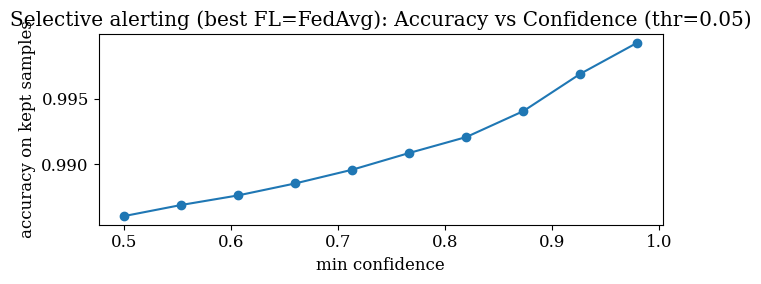

Saved: ./figs/selective_alerting_tradeoff.png


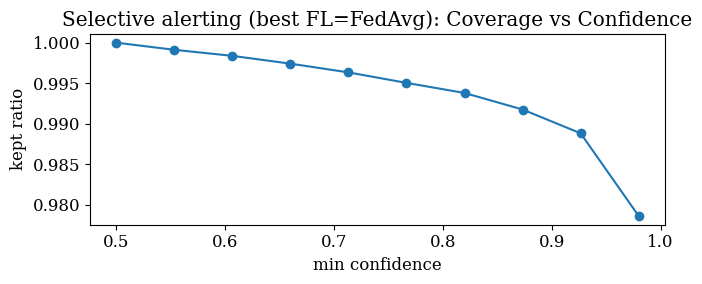

Saved: ./figs/selective_alerting_coverage.png


In [ ]:
# ----------------------------
# Step 17 — Selective Alerting Tradeoff Plot (fixed threshold)
# ----------------------------
banner("Step 17 — Selective Alerting Tradeoff Plot (fixed)")
print("Selective alerting: using confidence=max(p,1-p), and tuned thr (not 0.5).")

# FIX: Changed "F1" to "F1_Macro" to match the updated dictionary keys
best_row = pd.DataFrame([res_avg, res_prox, res_nova, res_dyn]).sort_values("F1_Macro", ascending=False).iloc[0]
best_name = best_row["ShortName"]
best_thr = float(best_row["thr"])

best_p = {
    "FedAvg":  res_avg["p_test"],
    "FedProx": res_prox["p_test"],
    "FedNova": res_nova["p_test"],
    "FedDyn":  res_dyn["p_test"],
}[best_name]

conf = np.maximum(best_p, 1.0 - best_p)
ths = np.linspace(0.50, 0.98, 10)

kept, accs = [], []
for t in ths:
    mask = conf >= t
    kept.append(mask.mean())
    if mask.sum() > 0:
        accs.append(accuracy_score(y_test[mask], (best_p[mask] >= best_thr).astype(int)))
    else:
        accs.append(np.nan)

plt.figure(figsize=(7, 3))
plt.plot(ths, accs, marker="o")
plt.title(f"Selective alerting (best FL={best_name}): Accuracy vs Confidence (thr={best_thr:.2f})")
plt.xlabel("min confidence")
plt.ylabel("accuracy on kept samples")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/selective_alerting_tradeoff.png", dpi=240)
plt.show()
plt.close()
print(f"Saved: {FIG_DIR}/selective_alerting_tradeoff.png")

plt.figure(figsize=(7, 3))
plt.plot(ths, kept, marker="o")
plt.title(f"Selective alerting (best FL={best_name}): Coverage vs Confidence")
plt.xlabel("min confidence")
plt.ylabel("kept ratio")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/selective_alerting_coverage.png", dpi=240)
plt.show()
plt.close()
print(f"Saved: {FIG_DIR}/selective_alerting_coverage.png")

Explainable AI (XAI) Initialization & Sampling

In [ ]:
# ============================================================
# Step 18 — XAI libs (SHAP + LIME)
# ============================================================
banner("Step 18 — XAI libs (SHAP + LIME)")
try:
    import shap
    from lime.lime_tabular import LimeTabularExplainer
    print("SHAP & LIME already installed.")
except Exception as e:
    print("Installing SHAP + LIME ...")
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "shap", "lime"])
    import shap
    from lime.lime_tabular import LimeTabularExplainer
    print("Installed SHAP & LIME.")


Step 18 — XAI libs (SHAP + LIME)
Installing SHAP + LIME ...
Installed SHAP & LIME.


In [ ]:
# ============================================================
# Step 19 — SHAP/LIME helper: safe sampling
# ============================================================
banner("Step 19 — XAI helpers (sampling)")
def sample_rows(X, n=800, seed=SEED):
    rng = np.random.RandomState(seed)
    if X.shape[0] <= n:
        return X, np.arange(X.shape[0])
    idx = rng.choice(np.arange(X.shape[0]), size=n, replace=False)
    return X[idx], idx

print("sample_rows helper ready.")


Step 19 — XAI helpers (sampling)
sample_rows helper ready.


Global & Local XAI for Centralized Baseline


Step 20 — SHAP (RandomForest) — Dense + Clear (Paper Ready)


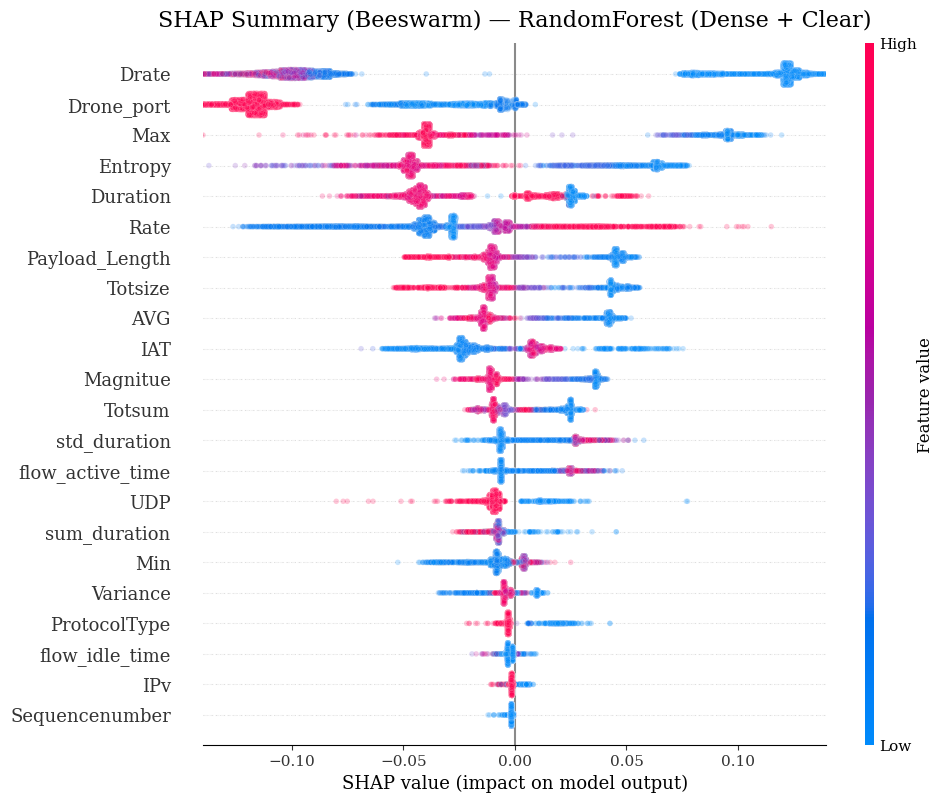

Saved beeswarm:
 - ./figs/shap_rf_beeswarm_DENSE_CLEAR.png
 - ./figs/shap_rf_beeswarm_DENSE_CLEAR.pdf
 - ./figs/shap_rf_beeswarm_DENSE_CLEAR.svg


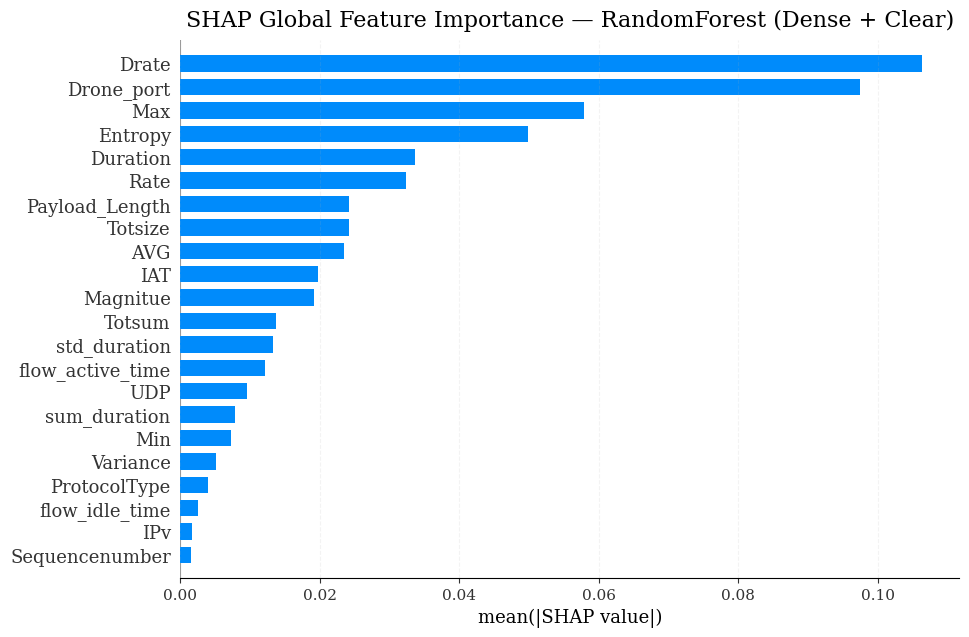

Saved bar importance:
 - ./figs/shap_rf_importance_bar_DENSE_CLEAR.png
 - ./figs/shap_rf_importance_bar_DENSE_CLEAR.pdf
 - ./figs/shap_rf_importance_bar_DENSE_CLEAR.svg


In [ ]:


# ============================================================
# Step 20 — SHAP (RandomForest)
#
# ============================================================
banner("Step 20 — SHAP (RandomForest) — Dense + Clear (Paper Ready)")

import os
import numpy as np
import matplotlib.pyplot as plt
import shap

# -----------------------------
# 0) Tunable controls (adjust if needed)
# -----------------------------
N_PLOT = 30000
MAX_DISPLAY = 22
DOT_SIZE = 16
DOT_ALPHA = 0.22
EDGE_ALPHA = 0.18
EDGE_LW = 0.25
FIGSIZE = (13.2, 9.0)
DPI_PNG = 700
XCLIP_PCT = 99.7
CMAP = plt.get_cmap("coolwarm")

SAVE_MAIN = "shap_rf_beeswarm_DENSE_CLEAR"
SAVE_BAR  = "shap_rf_importance_bar_DENSE_CLEAR"

# -----------------------------
# 1) Style (paper-friendly)
# -----------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

FEATURE_NAMES = feature_cols[:]  # must match X_* order

def sample_rows(X, n, seed):
    r = np.random.RandomState(seed)
    n = min(int(n), len(X))
    idx = r.choice(len(X), size=n, replace=False)
    return X[idx], idx

def get_pos_class_shap(shv):
    # binary: use class-1 contributions
    if isinstance(shv, list) and len(shv) == 2:
        return shv[1]
    if isinstance(shv, np.ndarray) and shv.ndim == 3 and shv.shape[-1] == 2:
        return shv[:, :, 1]
    return shv

# -----------------------------
# 2) Sample more rows for density
# -----------------------------
X_exp, _ = sample_rows(X_test, N_PLOT, seed=SEED + 77)

# -----------------------------
# 3) SHAP values (TreeExplainer for RF)
# -----------------------------
expl = shap.TreeExplainer(rf)
shv = expl.shap_values(X_exp, check_additivity=False)
shv1 = get_pos_class_shap(shv)

# -----------------------------
# 4) Beeswarm (Dense + Clear)
# -----------------------------
fig = plt.figure(figsize=FIGSIZE)

# draw plot (show=False so we can customize)
shap.summary_plot(
    shv1, X_exp,
    feature_names=FEATURE_NAMES,
    max_display=MAX_DISPLAY,
    show=False,
    plot_size=FIGSIZE,
    color=CMAP  # soften "too blue" look
)

ax = plt.gca()

# Make dots clearer: size + low alpha + subtle outline
for coll in ax.collections:
    try:
        coll.set_sizes([DOT_SIZE])
        coll.set_alpha(DOT_ALPHA)

        # subtle outline to separate dots (improves clarity)
        coll.set_edgecolor((1, 1, 1, EDGE_ALPHA))  # white-ish outline with low alpha
        coll.set_linewidth(EDGE_LW)

        # rasterize scatter for crisp output + lighter PDF
        coll.set_rasterized(True)
    except Exception:
        pass

# Reference line + subtle grid
ax.axvline(0, color="gray", linewidth=1.15, alpha=0.75)
ax.grid(axis="y", linestyle="--", alpha=0.14)

# Optional: clip x-range to dense region so center is not compressed
if XCLIP_PCT is not None:
    lim = float(np.percentile(np.abs(shv1.reshape(-1)), XCLIP_PCT))
    lim = max(lim, 1e-6)
    ax.set_xlim(-lim, lim)

# Make sure labels don’t cut off
plt.subplots_adjust(left=0.34, right=0.93, top=0.90, bottom=0.12)

ax.set_title("SHAP Summary (Beeswarm) — RandomForest (Dense + Clear)", pad=12)
ax.set_xlabel("SHAP value (impact on model output)")

base = os.path.join(FIG_DIR, SAVE_MAIN)
fig.savefig(base + ".png", dpi=DPI_PNG, bbox_inches="tight")
fig.savefig(base + ".pdf", bbox_inches="tight")
fig.savefig(base + ".svg", bbox_inches="tight")

plt.show()
plt.close(fig)

print("Saved beeswarm:")
print(" -", base + ".png")
print(" -", base + ".pdf")
print(" -", base + ".svg")

# -----------------------------
# 5) Global importance bar (matching style)
# -----------------------------
fig2 = plt.figure(figsize=(13.2, 6.9))
shap.summary_plot(
    shv1, X_exp,
    feature_names=FEATURE_NAMES,
    max_display=MAX_DISPLAY,
    plot_type="bar",
    show=False,
    plot_size=(13.2, 6.9)
)

ax2 = plt.gca()
ax2.grid(axis="x", linestyle="--", alpha=0.14)
plt.subplots_adjust(left=0.34, right=0.93, top=0.90, bottom=0.12)

ax2.set_title("SHAP Global Feature Importance — RandomForest (Dense + Clear)", pad=10)
ax2.set_xlabel("mean(|SHAP value|)")

base2 = os.path.join(FIG_DIR, SAVE_BAR)
fig2.savefig(base2 + ".png", dpi=DPI_PNG, bbox_inches="tight")
fig2.savefig(base2 + ".pdf", bbox_inches="tight")
fig2.savefig(base2 + ".svg", bbox_inches="tight")

plt.show()
plt.close(fig2)

print("Saved bar importance:")
print(" -", base2 + ".png")
print(" -", base2 + ".pdf")
print(" -", base2 + ".svg")

In [ ]:

# ============================================================
# Step 21 — LIME (RandomForest) — Local explanation
# ============================================================
banner("Step 21 — LIME (RandomForest) — Local explanation (FIXED)")

def rf_proba_2c(X):
    p1 = rf.predict_proba(X)[:, 1]
    p0 = 1 - p1
    return np.vstack([p0, p1]).T

lime = LimeTabularExplainer(
    training_data=X_train,
    feature_names=FEATURE_NAMES,
    class_names=["Normal(0)", "Attack(1)"],
    mode="classification",
    discretize_continuous=True
)

k = 0

# FIX: force LIME to compute explanation for label=1
exp = lime.explain_instance(
    X_test[k],
    rf_proba_2c,
    num_features=12,
    labels=(1,)  # <-- ensures label 1 exists in exp.local_exp
)

avail = list(exp.available_labels())
label_to_show = 1 if 1 in avail else avail[0]

print(f"LIME computed labels: {avail} | showing label={label_to_show} ({'Attack(1)' if label_to_show==1 else 'Normal(0)'})")
print("LIME top features (RandomForest):")
for feat, w in exp.as_list(label=label_to_show):
    print(f"  {feat:35s}  weight={w:+.4f}")

lime_path = f"{FIG_DIR}/lime_rf_local_k{k}.html"
with open(lime_path, "w", encoding="utf-8") as f:
    f.write(exp.as_html())
print(f"Saved: {lime_path}")


Step 21 — LIME (RandomForest) — Local explanation (FIXED)
LIME computed labels: [1] | showing label=1 (Attack(1))
LIME top features (RandomForest):
  -0.95 < Drone_port <= 0.95           weight=-0.1020
  0.33 < UDP <= 0.57                   weight=-0.0828
  DNS <= -0.04                         weight=+0.0556
  fin_flag_number <= -0.06             weight=+0.0431
  Telnet <= -0.00                      weight=-0.0373
  -0.30 < sum_duration <= 0.64         weight=-0.0228
  -1.07 < Duration <= 0.69             weight=-0.0189
  -0.52 < Rate <= -0.46                weight=-0.0179
  Sequencenumber <= -0.26              weight=-0.0177
  -0.11 < IAT <= -0.02                 weight=-0.0157
  ProtocolType <= -0.32                weight=+0.0152
  psh_flag_number <= -0.06             weight=-0.0125
Saved: ./figs/lime_rf_local_k0.html


Optimal Federated Model Reconstruction

In [ ]:


# ============================================================
# Step 22 — Build Best FL model for XAI
# ============================================================
banner("Step 22 — Build Best FL model for XAI")

def load_weights_npz(path):
    z = np.load(path)
    files = sorted(z.files, key=lambda s: int(s.split("_")[1]) if "_" in s else 0)
    return [z[f] for f in files]

all_fl = [res_avg, res_prox, res_nova, res_dyn]

# FIX: Changed "F1" to "F1_Macro" to match the updated dictionary keys
best = pd.DataFrame(all_fl).sort_values("F1_Macro", ascending=False).iloc[0].to_dict()
best_name = best["ShortName"]
best_thr = float(best["thr"])
best_T = float(best["T"])
print(f"Best FL model: {best_name} | thr={best_thr:.2f} | T={best_T:.2f}")

best_res = {"FedAvg": res_avg, "FedProx": res_prox, "FedNova": res_nova, "FedDyn": res_dyn}[best_name]
fl_model = build_fl_model(INPUT_DIM)

if "weights" in best_res and best_res["weights"] is not None:
    fl_model.set_weights(best_res["weights"])
    print(" FL model reconstructed from in-memory weights.")
elif "weights_path" in best_res and os.path.exists(best_res["weights_path"]):
    fl_model.set_weights(load_weights_npz(best_res["weights_path"]))
    print(f" FL model reconstructed from weights_path: {best_res['weights_path']}")
else:
    raise ValueError(" Best FL has no weights available. Re-run Step 16 and ensure weights saved.")

print("FL model ready for XAI.")


Step 22 — Build Best FL model for XAI
Best FL model: FedAvg | thr=0.05 | T=2.00
 FL model reconstructed from in-memory weights.
FL model ready for XAI.


Federated Explainability & Trust Validation


Step 23 — SHAP (Best FL model)


PermutationExplainer explainer: 301it [00:32,  9.23it/s]                         


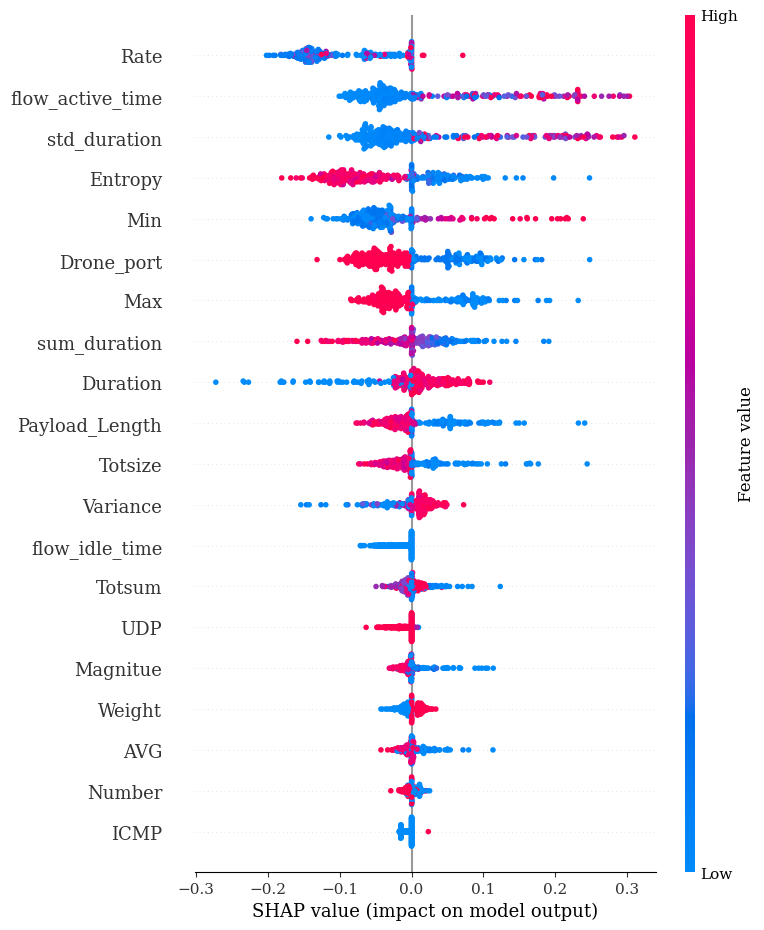

Saved: ./figs/shap_fl_summary_beeswarm.png


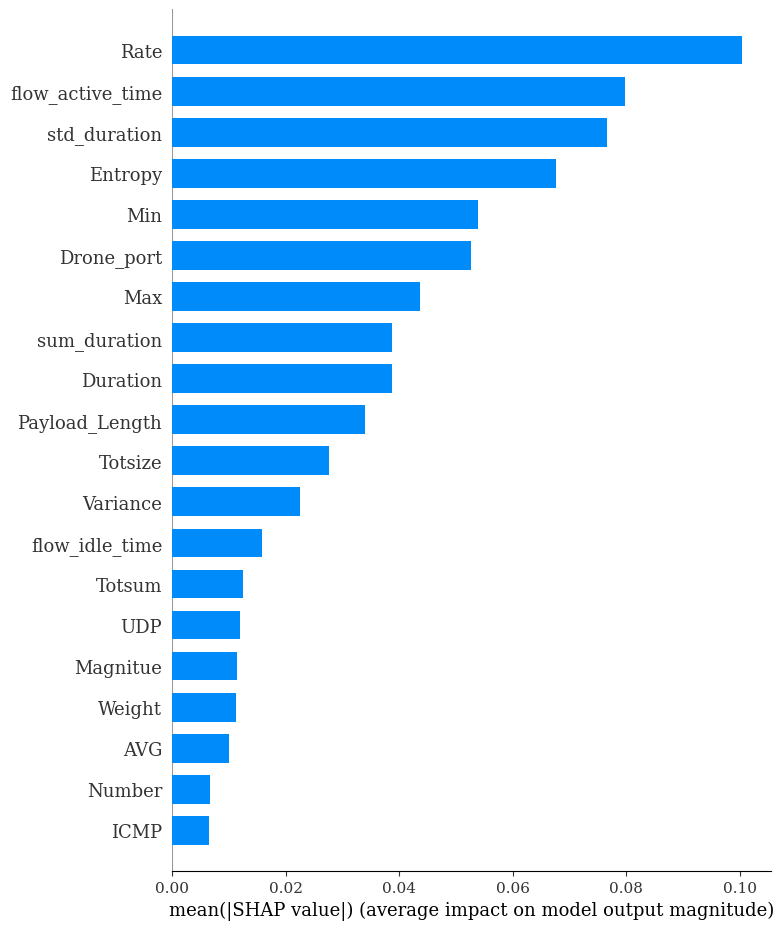

Saved: ./figs/shap_fl_importance_bar.png


In [ ]:
# Step 23 — SHAP for FL model (model-agnostic)
# ============================================================
banner("Step 23 — SHAP (Best FL model)")

def fl_attack_prob(X):
    X = np.asarray(X, dtype=np.float32)
    logits = fl_model(X, training=False).numpy().reshape(-1)
    p1 = 1.0 / (1.0 + np.exp(-(logits / best_T)))
    return p1

X_bg_fl, _  = sample_rows(X_train, n=200, seed=SEED+2)
X_exp_fl, _ = sample_rows(X_test,  n=300, seed=SEED+3)

masker = shap.maskers.Independent(X_bg_fl)
expl_fl = shap.Explainer(fl_attack_prob, masker)
sv_fl = expl_fl(X_exp_fl, max_evals=2*X_train.shape[1] + 1)

plt.figure(figsize=(10, 6))
shap.summary_plot(sv_fl.values, X_exp_fl, feature_names=FEATURE_NAMES, show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_fl_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print(f"Saved: {FIG_DIR}/shap_fl_summary_beeswarm.png")

plt.figure(figsize=(10, 6))
shap.summary_plot(sv_fl.values, X_exp_fl, feature_names=FEATURE_NAMES, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_fl_importance_bar.png", dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print(f"Saved: {FIG_DIR}/shap_fl_importance_bar.png")

In [ ]:
# ============================================================
# Step 24 — LIME for FL model
# ============================================================
banner("Step 24 — LIME (Best FL model)")

def fl_proba_2c(X):
    p1 = fl_attack_prob(X)
    p0 = 1 - p1
    return np.vstack([p0, p1]).T

lime_fl = LimeTabularExplainer(
    training_data=X_train,
    feature_names=FEATURE_NAMES,
    class_names=["Normal(0)", "Attack(1)"],
    mode="classification",
    discretize_continuous=True
)

k = 0
exp_fl = lime_fl.explain_instance(
    X_test[k],
    fl_proba_2c,
    num_features=12,
    labels=(1,)   # ensure Attack label explanation exists
)

avail = list(exp_fl.available_labels())
label_to_show = 1 if 1 in avail else avail[0]

print(f"LIME computed labels: {avail} | showing label={label_to_show} ({'Attack(1)' if label_to_show==1 else 'Normal(0)'})")
print(" LIME top features (Best FL):")
for feat, w in exp_fl.as_list(label=label_to_show):
    print(f"  {feat:35s}  weight={w:+.4f}")

lime_fl_path = f"{FIG_DIR}/lime_fl_local_{best_name}_k{k}.html"
with open(lime_fl_path, "w", encoding="utf-8") as f:
    f.write(exp_fl.as_html())
print(f"Saved: {lime_fl_path}")

banner("ALL STEPS 0 → 24 DONE")
print(f"Figures/exports folder: {FIG_DIR}")# =========================================================


Step 24 — LIME (Best FL model)
LIME computed labels: [1] | showing label=1 (Attack(1))
 LIME top features (Best FL):
  DNS <= -0.04                         weight=+0.6505
  psh_flag_number <= -0.06             weight=-0.1617
  ack_count <= -0.07                   weight=-0.1584
  rst_flag_number <= -0.03             weight=-0.1582
  ack_flag_number <= -0.08             weight=-0.1549
  fin_flag_number <= -0.06             weight=-0.1266
  rst_count <= -0.08                   weight=-0.1167
  urg_count <= -0.07                   weight=-0.1049
  ICMP <= -0.25                        weight=-0.0878
  Sequencenumber <= -0.26              weight=-0.0773
  Drate > -0.01                        weight=-0.0749
  syn_count <= -0.21                   weight=-0.0622
Saved: ./figs/lime_fl_local_FedAvg_k0.html

ALL STEPS 0 → 24 DONE
Figures/exports folder: ./figs
